In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
plt.style.use('seaborn')
import seaborn as sns  

import myMVP as mmvp
from scipy.cluster.hierarchy import dendrogram, linkage

### library related 

1. [`linkage`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)
  - input1: metric
  - input2: distance (Eulclidian, Ward, ....)
  - return $(y_{i1}, y_{i2}, y_{i3}, y_{i4})$
     - $y_{i1}, y_{i2}$: _ith_-cluster (will be formed new cluster) 
     - $y_{i3}$: distance b/w clusters $y_{i1}, y_{i2}$
     - $y_{i4}$: "represents the number of original observations in the newly formed cluster"
         - _how many singletons are in the cluster_




In [2]:
data = pd.read_csv("G:/python/data/dow/data.csv", index_col='Date', parse_dates=True)

In [3]:
data = data.drop(['DWDP', 'UTX'], axis=1)
dow = data['^DJI']
data = data.drop(["^DJI"], axis=1)

In [4]:
data.shape

(2814, 28)

<AxesSubplot:>

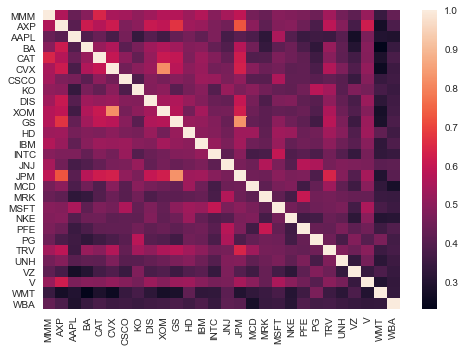

In [5]:
ret = data.pct_change().dropna()
corr = ret.corr()
sns.heatmap(corr)

In [6]:
# return correlation

corr = ret.corr()

# distance mmatrix 
d_corr = np.sqrt(0.5 * (1-corr))

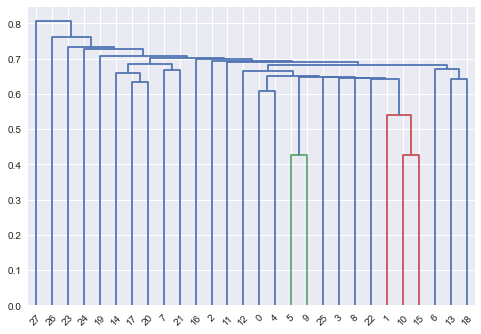

In [36]:
link = linkage(d_corr, 'single')  # single:min. dist
Z = pd.DataFrame(link)

d_gram = dendrogram(Z) 


### quasi-diagonalization 

In [82]:
sort_idx = get_quasi_diag(link)
#sort_idx

In [76]:
cov = ret.cov()
weights = get_rec_bipart(cov, sort_idx)

In [77]:
new_index = [ret.columns[i] for i in weights.index]
weights.index = new_index

In [78]:
weights

WBA     0.040636
WMT     0.067830
UNH     0.036455
VZ      0.065826
NKE     0.031488
JNJ     0.060096
MRK     0.040733
PFE     0.068546
KO      0.058980
PG      0.061567
MCD     0.050695
AAPL    0.023207
HD      0.031964
IBM     0.033178
MMM     0.047530
CAT     0.016409
CVX     0.018796
XOM     0.026166
V       0.023145
BA      0.011996
DIS     0.024255
TRV     0.046180
AXP     0.016458
GS      0.016048
JPM     0.018895
CSCO    0.021712
INTC    0.018047
MSFT    0.023160
dtype: float64

### the library are based on [here](https://github.com/TheRockXu/Hierarchical-Risk-Parity/blob/master/Hierarchical%20Clustering.ipynb)

In [72]:
def get_quasi_diag(link):
    
    # sort clustered items by distance
    
    link = link.astype(int)
    
    # get the first and the second item of the last tuple
    sort_ix = pd.Series([link[-1,0], link[-1,1]]) 
    
    # the total num of items is the third item of the last list
    num_items = link[-1, 3]
    
    # if the max of sort_ix is bigger than or equal to the max_items
    while sort_ix.max() >= num_items:
        # assign sort_ix index with 24 x 24
        sort_ix.index = range(0, sort_ix.shape[0]*2, 2) # odd numers as index
        
        df0 = sort_ix[sort_ix >= num_items] # find clusters
        
        #print(df0)
        #break 

        # df0 contain even index and cluster index
        i = df0.index
        j = df0.values - num_items # 
        
        sort_ix[i] = link[j,0] # item 1
        #print(link[j,0])
        
        df0  = pd.Series(link[j, 1], index=i+1)
        
        sort_ix = sort_ix.append(df0)
        sort_ix = sort_ix.sort_index()
        
        sort_ix.index = range(sort_ix.shape[0])
        
    
    return sort_ix.tolist()

In [17]:
def get_cluster_var(cov, c_items):
    cov_ = cov.iloc[c_items, c_items] # matrix slice
    # calculate the inversev-variance portfolio
    ivp = 1./np.diag(cov_)
    ivp/=ivp.sum()
    w_ = ivp.reshape(-1,1)
    c_var = np.dot(np.dot(w_.T, cov_), w_)[0,0]
    return c_var
    
def get_rec_bipart(cov, sort_ix):
    # compute HRP allocation
    # intialize weights of 1
    w = pd.Series(1, index=sort_ix)
    
    # intialize all items in one cluster
    c_items = [sort_ix]
    while len(c_items) > 0:
        # bisection
        """
        [[3, 6, 0, 9, 2, 4, 13], [5, 12, 8, 10, 7, 1, 11]]
        [[3, 6, 0], [9, 2, 4, 13], [5, 12, 8], [10, 7, 1, 11]]
        [[3], [6, 0], [9, 2], [4, 13], [5], [12, 8], [10, 7], [1, 11]]
        [[6], [0], [9], [2], [4], [13], [12], [8], [10], [7], [1], [11]]
        """
        c_items = [i[int(j):int(k)] for i in c_items for j,k in 
                   ((0,len(i)/2),(len(i)/2,len(i))) if len(i)>1]
        
        # now it has 2
        for i in range(0, len(c_items), 2):
            
            c_items0 = c_items[i] # cluster 1
            c_items1 = c_items[i+1] # cluter 2
            
            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            
            alpha = 1 - c_var0/(c_var0+c_var1)
            
            w[c_items0] *= alpha
            w[c_items1] *=1-alpha
    return w